<a href="https://colab.research.google.com/github/SriVallipuram/Arduino-WavGat-Drivers/blob/master/python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import os
os.environ['KAGGLE_TOKEN'] = 'KGAT_5197afe04823c7e67f53ba5c27fa81cf'

!kaggle datasets download -d dansbecker/melbourne-housing-snapshot --unzip

Dataset URL: https://www.kaggle.com/datasets/dansbecker/melbourne-housing-snapshot
License(s): CC-BY-NC-SA-4.0
100% 451k/451k [00:00<00:00, 83.0MB/s]



In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error

In [30]:
df = pd.read_csv('melb_data.csv').dropna()
print(df.columns)
print(df.dtypes)




Index(['Suburb', 'Address', 'Rooms', 'Type', 'Price', 'Method', 'SellerG',
       'Date', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car',
       'Landsize', 'BuildingArea', 'YearBuilt', 'CouncilArea', 'Lattitude',
       'Longtitude', 'Regionname', 'Propertycount'],
      dtype='object')
Suburb            object
Address           object
Rooms              int64
Type              object
Price            float64
Method            object
SellerG           object
Date              object
Distance         float64
Postcode         float64
Bedroom2         float64
Bathroom         float64
Car              float64
Landsize         float64
BuildingArea     float64
YearBuilt        float64
CouncilArea       object
Lattitude        float64
Longtitude       float64
Regionname        object
Propertycount    float64
dtype: object


In [34]:
# Target = what you are predicting
target = df['Price']

# Features = inputs the model learns from
# Start simple - numeric columns only
features = ['Rooms','Bathroom','Landsize','BuildingArea','YearBuilt','Lattitude','Longtitude']
X = df[features]
y = y[X.index] # keep y aligned to X

In [35]:
X_train,X_test,y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(f"Training rows: {len(X_train)}, Test rows: {len(X_test)}")

Training rows: 4956, Test rows: 1240


In [36]:
# create a model object
model = DecisionTreeRegressor(random_state=42)
#.fit() = "learn from this data"
model.fit(X_train,y_train)

DecisionTreeRegressor(random_state=42)

In [39]:
#MAE on training set
train_prediction = model.predict(X_train)
train_mae = mean_absolute_error(y_train,train_prediction)

#MAE on test set
test_prediction = model.predict(X_test)
test_mae = mean_absolute_error(y_test,test_prediction)

print(f" Train MAE : ${train_mae:,.0f}")
print(f"Test MAE : ${test_mae:,.0f}")

 Train MAE : $332
Test MAE : $246,127


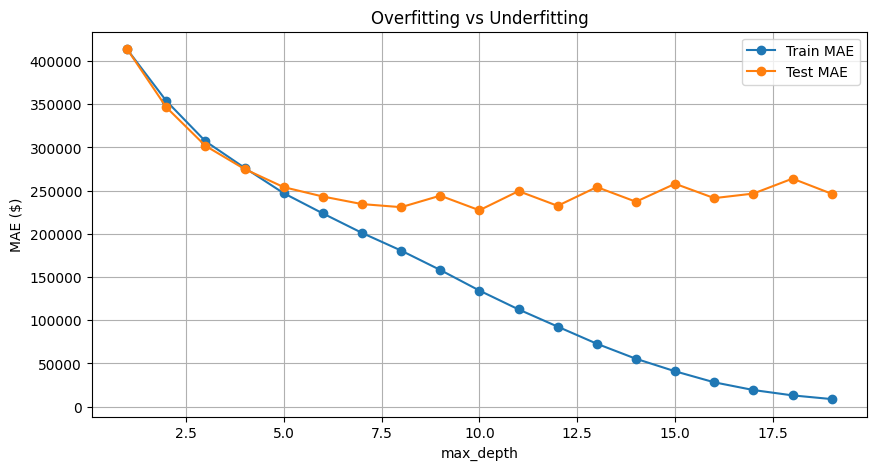

In [40]:
# Detect overfitting/Underfitting
train_maes = []
test_maes = []
depths = range(1,20)

for depth in depths:
  m = DecisionTreeRegressor(max_depth = depth,random_state=42)
  m.fit(X_train,y_train)
  train_maes.append(mean_absolute_error(y_train,m.predict(X_train)))
  test_maes.append(mean_absolute_error(y_test,m.predict(X_test)))

plt.figure(figsize=(10,5))
plt.plot(depths,train_maes,label = 'Train MAE', marker = 'o')
plt.plot(depths,test_maes, label = 'Test MAE',marker = 'o')
plt.xlabel ('max_depth')
plt.ylabel ('MAE ($)')
plt.title("Overfitting vs Underfitting")
plt.legend()
plt.grid(True)
plt.show()

In [41]:
# Find the best depth with lowest test MAE
best_depth = depths[test_maes.index(min(test_maes))]
print(f"Best Max depth : {best_depth}")

# Train final model with that depth
final_model = DecisionTreeRegressor(max_depth = best_depth,random_state=42)

final_model.fit(X_train,y_train)
final_mae = mean_absolute_error(y_test,final_model.predict(X_test))
print(f"Final Test MAE: ${final_mae:,>0f}")

Best Max depth : 10
Final Test MAE: $227156.935441
